# Margin Optimization Through Data-Driven Wine Segmentation


## Company: Vinhosevinhos
## Use Case: Pricing & Inventory Strategy via Unsupervised Learning

## 1. Define the Clustering Objective

### Business Context

Vinhosevinhos manages a large wine portfolio (1,400+ SKUs) with significant variation in:

- Price

- Alcohol content

- Age

- Oak aging

- Popularity (reviews)

- Storage potential

However, pricing and promotion decisions are made:

- At the individual SKU level

- Or using broad categories (Red vs White)

### Core Business Question

How can we segment wines into economically meaningful groups to optimize pricing, promotion, and inventory decisions without relying on predefined labels?

### Why Clustering?

Clustering allows us to:

- Identify substitutable wines

- Detect pricing inconsistencies within similar products

- Create margin-based product bands

- Enable segment-level pricing strategy instead of SKU-by-SKU chaos

Margin is optimized at the segment level, not at the individual SKU level.

### Analytical Objective

We aim to:

1. Cluster wines based on economic and product features

2. Identify margin-relevant segments

3. Compare pricing and demand within clusters

4. Advice pricing and inventory adjustments

### Expected Business Impact

- Higher gross margin consistency

- Smarter discounting strategy

- Reduced overstock of low-margin substitutes

- Protection of premium positioning

## 2. Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## 3. Data Loading

In [ ]:
!ls /mnt/data/public/vinhosevinhos

In [ ]:
file_path = '/mnt/data/public/vinhosevinhos/wine_data.json'
df_wine = pd.read_json(file_path)

In [ ]:
file_path = 'wine_data.json'
df_wine = pd.read_json(file_path)

In [ ]:
list(df_wine.columns)

['Name',
 'URL Product',
 'Sku',
 'Image',
 'Num Reviews',
 'Grape',
 'Type',
 'Alcoholic Degree',
 'Harvest',
 'Region',
 'Winery',
 'Vineyard',
 'Wine Class',
 'Classification',
 'Volume',
 'Maturation',
 'Temperature',
 'Storage Potential',
 'Visual',
 'Olfaction',
 'Palate',
 'Pairing',
 'Closure',
 'Price',
 'Description']

In [ ]:
df_wine.head()

,Name,URL Product,Sku,Image,Num Reviews,Grape,Type,Alcoholic Degree,Harvest,Region,Winery,Vineyard,Wine Class,Classification,Volume,Maturation,Temperature,Storage Potential,Visual,Olfaction,Palate,Pairing,Closure,Price,Description
0,Don Laurindo Don Tannat,https://www.vinhosevinhos.com/don-laurindo-don...,27423,https://www.vinhosevinhos.com/media/catalog/pr...,0,Tannat,Tinto,14%,2020,Serra Gaúcha,Don Laurindo,Vale dos Vinhedos,Fino,Seco,750 ml,"Barril de carvalho francês por 24 meses, engar...",18 a 20°C,10 anos,Muito bom aspecto de cor vermelho rubi intenso.,"Concentrado, intenso, notas tostadas e amadeir...","Amplo, potente, volumoso, equilibrado com fina...",Pratos de sabor acentuado.,Rolha,"R$265,00","Ademir Brandelli, enólogo fundador da Don Laur..."
1,Amitié Chardonnay OAK Barrel,https://www.vinhosevinhos.com/amitie-chardonna...,35380,https://www.vinhosevinhos.com/media/catalog/pr...,1,Chardonnay,Branco,14%,2022,Campanha Gaúcha,Amitié,Campanha gaúcha,Fino,Seco,750 ml,Maturação de 12 meses em barricas de carvalho ...,8º a 10º C,5 a 7 anos,"Límpido e brilhante, coloração amarelo palha c...",Um vinho marcante com notas de frutas cítricas...,"Vinho complexo e untuoso, com acidez equilibra...","Frutos do mar, bacalhau, massas e risotos.",Rolha e Cera,"R$179,00",Amitié Chardonnay Oak Barrel é uma edição limi...
2,Valparaiso Vitale Sangiovese,https://www.vinhosevinhos.com/valparaiso-vital...,35378,https://www.vinhosevinhos.com/media/catalog/pr...,0,Sangiovese,Tinto,"12,5%",2020,Serra Gaúcha,Valparaiso,Vila Rica - Barão - RS,Fino,Seco,750 ml,Sem passagem por barrica,14º a 16ºC,5 a 7 anos,None,Aroma de frutas vermelhas com notas terrosas e...,"No paladar, apresenta todo o frescor da varied...","Ideal para acompanhar pratos à base de massas,...",Rolha,"R$126,00",A Valparaiso preserva toda pureza e integridad...
3,Tempos de Góes Míneres Syrah,https://www.vinhosevinhos.com/goes-tempos-mine...,35369,https://www.vinhosevinhos.com/media/catalog/pr...,1,Shiraz,Tinto,"12,9%",2020,Minas Gerais,Góes,Andradas - Minas Gerais,Fino,Seco,750 ml,100% do lote por 6 meses em carvalho francês d...,15 a 17ºC,5 a 7 anos,Vinho tinto encorpado de cor rubi e reflexos p...,"Aroma elegante e pronunciado, exibe notas de b...","No sabor apresenta taninos vigorosos, que acar...",A boa estrutura de corpo combinada com a rique...,Rolha,"R$98,80","Nas terras e caminhos reais nasce o fruto, rel..."
4,Tempos de Góes Philosophia Cabernet Franc,https://www.vinhosevinhos.com/goes-philosophia...,35368,https://www.vinhosevinhos.com/media/catalog/pr...,0,Cabernet Franc,Tinto,"13,5%",2021,São Paulo,Góes,São Roque - São Paulo,Fino,Seco,750 ml,100% do lote com passagem de 12 meses de barri...,16 a 17ºC,10 anos,"Límpido e brilhante, apresenta excelente color...",Aroma frutado marcante e intenso para destaque...,No paladar apresenta excelente estrutura em bo...,"Queijos maturados, pratos com carne vermelha c...",Rolha,"R$165,00",Tempos de Góes Philosophia Cabernet Franc de ...


## 4. Exploratory Data Analysis (EDA)

In [ ]:
# Exploring the dataset

rows = []
missing_pct = df_wine.isna().mean().mul(100).round(2)

for col in df_wine.columns:
    s = df_wine[col].dropna()
    n = len(s)
    uniq = s.nunique()
    samples = s.unique()[:10].tolist()

    # numeric check
    s_num = pd.to_numeric(s, errors="coerce")
    is_numeric = (n > 0) and (s_num.notna().mean() > 0.95)

    # identifier check
    is_id = (n > 0) and (uniq >= 0.95 * n)

    # suggested type
    if uniq == 1:
        t = "constant"
    elif is_id:
        t = "identifier"
    elif uniq == 2:
        t = "binary"
    elif is_numeric:
        t = "numeric"
    else:
        t = "categorical"

    # numeric stats
    min_v = max_v = mean_v = None
    if t == "numeric":
        min_v, max_v, mean_v = s_num.min(), s_num.max(), s_num.mean()

    rows.append({
        "Column": col,
        "Unique Values": uniq,
        "Sample Values": samples,
        "Suggested Type": t,
        "Missing %": float(missing_pct[col]),
        "Min": min_v,
        "Max": max_v,
        "Mean": mean_v})

diagnosis_df = pd.DataFrame(rows)
diagnosis_df

,Column,Unique Values,Sample Values,Suggested Type,Missing %,Min,Max,Mean
0,Name,1407,"[Don Laurindo Don Tannat, Amitié Chardonnay OA...",identifier,0.00,NaN,NaN,NaN
1,URL Product,1408,[https://www.vinhosevinhos.com/don-laurindo-do...,identifier,0.00,NaN,NaN,NaN
2,Sku,1408,"[27423, 35380, 35378, 35369, 35368, 35365, 353...",identifier,0.00,NaN,NaN,NaN
3,Image,1408,[https://www.vinhosevinhos.com/media/catalog/p...,identifier,0.00,NaN,NaN,NaN
4,Num Reviews,8,"[0, 1, 2, 4, 3, 7, 5, 6]",numeric,0.00,0.0,7.0,0.286932
5,Grape,208,"[Tannat, Chardonnay, Sangiovese, Shiraz, Caber...",categorical,2.98,NaN,NaN,NaN
6,Type,3,"[Tinto, Branco, Rosé]",categorical,0.85,NaN,NaN,NaN
7,Alcoholic Degree,77,"[14%, 12,5%, 12,9%, 13,5%, 12,8%, 12,3%, 18%, ...",categorical,1.28,NaN,NaN,NaN
8,Harvest,63,"[2020, 2022, 2021, 2011, Não Safrado, 2023, 20...",categorical,1.92,NaN,NaN,NaN
9,Region,11,"[Serra Gaúcha, Campanha Gaúcha, Minas Gerais, ...",categorical,5.18,NaN,NaN,NaN


## 5. Feature Selection

In [ ]:
# Selecting important features for the business case

selected_columns = [
    "Price",              # margin driver
    "Num Reviews",        # demand signal
    "Alcoholic Degree",   # cost/style proxy
    "Type",               # red/white/rose segmentation
    "Grape",              # differentiation driver
    "Wine Class",         # quality tier
    "Region",             # geographic premium signal
    "Harvest",            # vintage positioning
    "Maturation",         # oak/cost proxy
    "Storage Potential"   # holding cost + premium signal
]
df_wine_selected = df_wine[selected_columns].copy()

In [ ]:
df_wine_selected.head()

,Price,Num Reviews,Alcoholic Degree,Type,Grape,Wine Class,Region,Harvest,Maturation,Storage Potential
0,"R$265,00",0,14%,Tinto,Tannat,Fino,Serra Gaúcha,2020,"Barril de carvalho francês por 24 meses, engar...",10 anos
1,"R$179,00",1,14%,Branco,Chardonnay,Fino,Campanha Gaúcha,2022,Maturação de 12 meses em barricas de carvalho ...,5 a 7 anos
2,"R$126,00",0,"12,5%",Tinto,Sangiovese,Fino,Serra Gaúcha,2020,Sem passagem por barrica,5 a 7 anos
3,"R$98,80",1,"12,9%",Tinto,Shiraz,Fino,Minas Gerais,2020,100% do lote por 6 meses em carvalho francês d...,5 a 7 anos
4,"R$165,00",0,"13,5%",Tinto,Cabernet Franc,Fino,São Paulo,2021,100% do lote com passagem de 12 meses de barri...,10 anos


In [ ]:
# Exploring the dataset with selected features

rows = []
missing_pct = df_wine_selected.isna().mean().mul(100).round(2)

for col in df_wine_selected.columns:
    s = df_wine_selected[col].dropna()
    n = len(s)
    uniq = s.nunique()
    samples = s.unique()[:10].tolist()

    # numeric check
    s_num = pd.to_numeric(s, errors="coerce")
    is_numeric = (n > 0) and (s_num.notna().mean() > 0.95)

    # identifier check
    is_id = (n > 0) and (uniq >= 0.95 * n)

    # suggested type
    if uniq == 1:
        t = "constant"
    elif is_id:
        t = "identifier"
    elif uniq == 2:
        t = "binary"
    elif is_numeric:
        t = "numeric"
    else:
        t = "categorical"

    # numeric stats
    min_v = max_v = mean_v = None
    if t == "numeric":
        min_v, max_v, mean_v = s_num.min(), s_num.max(), s_num.mean()

    rows.append({
        "Column": col,
        "Unique Values": uniq,
        "Sample Values": samples,
        "Suggested Type": t,
        "Missing %": float(missing_pct[col]),
        "Min": min_v,
        "Max": max_v,
        "Mean": mean_v})

diagnosis_df = pd.DataFrame(rows)
diagnosis_df

,Column,Unique Values,Sample Values,Suggested Type,Missing %,Min,Max,Mean
0,Price,311,"[R$265,00, R$179,00, R$126,00, R$98,80, R$165,...",categorical,0.00,NaN,NaN,NaN
1,Num Reviews,8,"[0, 1, 2, 4, 3, 7, 5, 6]",numeric,0.00,0.0,7.0,0.286932
2,Alcoholic Degree,77,"[14%, 12,5%, 12,9%, 13,5%, 12,8%, 12,3%, 18%, ...",categorical,1.28,NaN,NaN,NaN
3,Type,3,"[Tinto, Branco, Rosé]",categorical,0.85,NaN,NaN,NaN
4,Grape,208,"[Tannat, Chardonnay, Sangiovese, Shiraz, Caber...",categorical,2.98,NaN,NaN,NaN
5,Wine Class,7,"[Fino, Licoroso, Nobre, De mesa, Frisante, Lev...",categorical,1.14,NaN,NaN,NaN
6,Region,11,"[Serra Gaúcha, Campanha Gaúcha, Minas Gerais, ...",categorical,5.18,NaN,NaN,NaN
7,Harvest,63,"[2020, 2022, 2021, 2011, Não Safrado, 2023, 20...",categorical,1.92,NaN,NaN,NaN
8,Maturation,687,"[Barril de carvalho francês por 24 meses, enga...",categorical,14.06,NaN,NaN,NaN
9,Storage Potential,46,"[10 anos, 5 a 7 anos, Indeterminado, Indetermi...",categorical,2.63,NaN,NaN,NaN


## 6. Data Preprocessing per Features

In [ ]:
# Price

# Price to numeric
df_wine_selected["Price"] = (
    df_wine_selected["Price"]
    .astype(str)
    .str.replace("R$", "", regex=False)
    .str.replace(" ", "", regex=False)
    .str.replace(r"\.", "", regex=True)
    .str.replace(",", ".", regex=False))

df_wine_selected["Price"] = pd.to_numeric(
    df_wine_selected["Price"],
    errors="coerce")

# Log transform price
df_wine_selected["Log_Price"] = np.log1p(df_wine_selected["Price"])

# Drop original price column
df_wine_selected.drop(columns=["Price"], errors="ignore", inplace=True)

In [ ]:
# Alcoholic Degree

# Alcoholic Degree to numeric
df_wine_selected["Alcoholic Degree"] = (
    df_wine_selected["Alcoholic Degree"]
    .astype(str)
    .str.extract(r"(\d+[.,]?\d*)")[0]
    .str.replace(",", ".", regex=False)
    .astype(float)
)

# Impute missing values
df_wine_selected["Alcoholic Degree"] = (
    df_wine_selected["Alcoholic Degree"]
    .fillna(df_wine_selected["Alcoholic Degree"].median())
)

# Cap alcoholic degree
df_wine_selected["Alcoholic Degree"] = df_wine_selected["Alcoholic Degree"].clip(upper=20)


In [ ]:
# Grape

# Collapse all multi-grape into "Blend"
df_wine_selected["Grape_Clean"] = df_wine_selected["Grape"]

df_wine_selected.loc[
    df_wine_selected["Grape"].str.contains(",", na=False),
    "Grape_Clean"
] = "Blend"

# Keep top 15 single grapes
top_n = 15

top_grapes = (
    df_wine_selected["Grape_Clean"]
    .value_counts()
    .nlargest(top_n)
    .index)

df_wine_selected["Grape_Final"] = df_wine_selected["Grape_Clean"].where(
    df_wine_selected["Grape_Clean"].isin(top_grapes),
    "Other")

# Drop original Grape column
df_wine_selected.drop(columns=["Grape", "Grape_Clean"], inplace=True)

In [ ]:
# Harvest

# Extract numeric year
df_wine_selected["Harvest_Year"] = (
    df_wine_selected["Harvest"]
    .astype(str)
    .str.extract(r"(19\d{2}|20\d{2})")[0])

df_wine_selected["Harvest_Year"] = pd.to_numeric(
    df_wine_selected["Harvest_Year"],
    errors="coerce")

# Flag non-vintage
df_wine_selected["Is_Non_Vintage"] = (
    df_wine_selected["Harvest"]
    .str.contains("não|sob|consulta", case=False, na=False)
    .astype(int))

# Flag multi-vintage
harv = df_wine_selected["Harvest"].astype(str)

df_wine_selected["Is_Multi_Vintage"] = (
    harv.str.contains(r"\bblend\b|,|\b\d{4}\s*e\s*\d{4}\b", case=False, na=False, regex=True)
    .astype(int))

# Compute wine age
current_year = 2025

df_wine_selected["Wine_Age"] = (
    current_year - df_wine_selected["Harvest_Year"])

# Impute missing age
df_wine_selected["Wine_Age"] = df_wine_selected["Wine_Age"].fillna(
    df_wine_selected["Wine_Age"].median())

# Drop Raw Harvest
df_wine_selected.drop(columns=["Harvest", 'Harvest_Year'], inplace=True)

In [ ]:
# Maturation

# Oak_Aged (0/1)
df_wine_selected["Oak_Aged"] = (
    df_wine_selected["Maturation"]
    .astype(str)
    .str.contains(r"carvalho|barric|barriq|barris|madeira|staves|aduelas|chips|lascas", case=False, na=False)
    .astype(int))

# Force "Sem passagem por barrica" to 0 (explicit no-oak)
df_wine_selected.loc[
    df_wine_selected["Maturation"].astype(str).str.contains("sem passagem por barrica", case=False, na=False),
    "Oak_Aged"] = 0

# Oak_Months (numeric)
df_wine_selected["Oak_Months"] = (
    df_wine_selected["Maturation"]
    .astype(str)
    .str.extract(r"(\d{1,3})\s*(?:mes|meses|mês|mths|months|dias)")[0])

df_wine_selected["Oak_Months"] = pd.to_numeric(df_wine_selected["Oak_Months"], errors="coerce")

# Impute oak months missing
df_wine_selected.loc[df_wine_selected["Oak_Aged"] == 0, "Oak_Months"] = 0

# Impute median for the remaining missing
median_oak = df_wine_selected.loc[df_wine_selected["Oak_Aged"] == 1, "Oak_Months"].median()
df_wine_selected["Oak_Months"] = df_wine_selected["Oak_Months"].fillna(median_oak)

# Clip oak months
df_wine_selected["Oak_Months"] = df_wine_selected["Oak_Months"].clip(upper=60)

# Drop the raw text column
df_wine_selected.drop(columns=["Maturation"], inplace=True)


In [ ]:
# Storage Potential

# Extract numeric values
sp = df_wine_selected["Storage Potential"].astype(str)
numbers = sp.str.extractall(r'(\d+)')[0].unstack()
numbers = numbers.apply(pd.to_numeric, errors="coerce")
df_wine_selected["Storage_Potential_Years"] = numbers.mean(axis=1)

# Handle special cases

# Consumo rápido to 1 year
df_wine_selected.loc[
    sp.str.contains("consumo", case=False, na=False),
    "Storage_Potential_Years"] = 1

# "luas" to convert to years (12 luas ≈ 1 year)
mask_luas = sp.str.contains("lua", case=False, na=False)
luas = sp[mask_luas].str.extract(r'(\d+)')[0].astype(float)

df_wine_selected.loc[mask_luas, "Storage_Potential_Years"] = luas / 12

# Indeterminado to set to median
median_sp = df_wine_selected["Storage_Potential_Years"].median()

df_wine_selected.loc[
    sp.str.contains("indeterm", case=False, na=False),
    "Storage_Potential_Years"] = median_sp

# Impute missing values
df_wine_selected["Storage_Potential_Years"] = df_wine_selected["Storage_Potential_Years"].fillna(median_sp)
df_wine_selected.drop(columns=["Storage Potential"], inplace=True)


In [ ]:
# Impute categorical missing values
categorical_cols = ["Type", "Wine Class", "Region"]

for col in categorical_cols:
    df_wine_selected[col] = df_wine_selected[col].fillna("Unknown")

In [ ]:
# Exploring the cleaned dataset

rows = []
missing_pct = df_wine_selected.isna().mean().mul(100).round(2)

for col in df_wine_selected.columns:
    s = df_wine_selected[col].dropna()
    n = len(s)
    uniq = s.nunique()
    samples = s.unique()[:10].tolist()

    # numeric check
    s_num = pd.to_numeric(s, errors="coerce")
    is_numeric = (n > 0) and (s_num.notna().mean() > 0.95)

    # identifier check
    is_id = (n > 0) and (uniq >= 0.95 * n)

    # suggested type
    if uniq == 1:
        t = "constant"
    elif is_id:
        t = "identifier"
    elif uniq == 2:
        t = "binary"
    elif is_numeric:
        t = "numeric"
    else:
        t = "categorical"

    # numeric stats
    min_v = max_v = mean_v = None
    if t == "numeric":
        min_v, max_v, mean_v = s_num.min(), s_num.max(), s_num.mean()

    rows.append({
        "Column": col,
        "Unique Values": uniq,
        "Sample Values": samples,
        "Suggested Type": t,
        "Missing %": float(missing_pct[col]),
        "Min": min_v,
        "Max": max_v,
        "Mean": mean_v})

diagnosis_df = pd.DataFrame(rows)
diagnosis_df

,Column,Unique Values,Sample Values,Suggested Type,Missing %,Min,Max,Mean
0,Num Reviews,8,"[0, 1, 2, 4, 3, 7, 5, 6]",numeric,0.0,0.000000,7.000000,0.286932
1,Alcoholic Degree,63,"[14.0, 12.5, 12.9, 13.5, 12.8, 12.3, 18.0, 13....",numeric,0.0,7.500000,20.000000,12.925575
2,Type,4,"[Tinto, Branco, Rosé, Unknown]",categorical,0.0,NaN,NaN,NaN
3,Wine Class,8,"[Fino, Licoroso, Nobre, De mesa, Unknown, Fris...",categorical,0.0,NaN,NaN,NaN
4,Region,12,"[Serra Gaúcha, Campanha Gaúcha, Minas Gerais, ...",categorical,0.0,NaN,NaN,NaN
5,Log_Price,311,"[5.583496308781699, 5.19295685089021, 4.844187...",numeric,0.0,2.282382,7.048386,4.635892
6,Grape_Final,16,"[Tannat, Chardonnay, Other, Shiraz, Cabernet F...",categorical,0.0,NaN,NaN,NaN
7,Is_Non_Vintage,2,"[0, 1]",binary,0.0,NaN,NaN,NaN
8,Is_Multi_Vintage,2,"[0, 1]",binary,0.0,NaN,NaN,NaN
9,Wine_Age,24,"[5.0, 3.0, 4.0, 14.0, 2.0, 11.0, 16.0, 6.0, 18...",numeric,0.0,1.000000,74.000000,4.176136


In [ ]:
df_wine_cleaned = df_wine_selected.copy()

In [ ]:
df_wine_cleaned.head()

,Num Reviews,Alcoholic Degree,Type,Wine Class,Region,Log_Price,Grape_Final,Is_Non_Vintage,Is_Multi_Vintage,Wine_Age,Oak_Aged,Oak_Months,Storage_Potential_Years
0,0,14.0,Tinto,Fino,Serra Gaúcha,5.583496,Tannat,0,0,5.0,1,24.0,10.0
1,1,14.0,Branco,Fino,Campanha Gaúcha,5.192957,Chardonnay,0,0,3.0,1,12.0,6.0
2,0,12.5,Tinto,Fino,Serra Gaúcha,4.844187,Other,0,0,5.0,0,0.0,6.0
3,1,12.9,Tinto,Fino,Minas Gerais,4.603168,Shiraz,0,0,5.0,1,6.0,6.0
4,0,13.5,Tinto,Fino,São Paulo,5.111988,Cabernet Franc,0,0,4.0,1,12.0,10.0


## 7. Feature Engineering

In [ ]:
# Define Feature Groups
numeric_cols = [
    "Log_Price",
    "Num Reviews",
    "Alcoholic Degree",
    "Wine_Age",
    "Oak_Months",
    "Storage_Potential_Years"]

binary_cols = [
    "Oak_Aged",
    "Is_Non_Vintage",
    "Is_Multi_Vintage"]

categorical_cols = [
    "Type",
    "Wine Class",
    "Region",
    "Grape_Final"]

In [ ]:
# One-Hot Encode Categoricals
df_wine_encoded = pd.get_dummies(
    df_wine_cleaned,
    columns=categorical_cols,
    drop_first=False,
    dtype=int)

In [ ]:
# Scale Numeric Features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_wine_encoded[numeric_cols] = scaler.fit_transform(df_wine_encoded[numeric_cols])

In [ ]:
df_wine_encoded.head()

,Num Reviews,Alcoholic Degree,Log_Price,Is_Non_Vintage,Is_Multi_Vintage,Wine_Age,Oak_Aged,Oak_Months,Storage_Potential_Years,Type_Branco,Type_Rosé,Type_Tinto,Type_Unknown,Wine Class_De mesa,Wine Class_Espumante,Wine Class_Fino,Wine Class_Frisante,Wine Class_Leve,Wine Class_Licoroso,Wine Class_Nobre,Wine Class_Unknown,Region_Brasília,Region_Campanha Gaúcha,Region_Campos de Cima da Serra,Region_Goiás,Region_Minas Gerais,Region_Planalto Catarinense,Region_Serra Catarinense,Region_Serra Gaúcha,Region_Serra do Sudeste,Region_São Paulo,Region_Unknown,Region_Vale do São Francisco,Grape_Final_Americana,Grape_Final_Assemblage,Grape_Final_Blend,Grape_Final_Cabernet Franc,Grape_Final_Cabernet Sauvignon,Grape_Final_Chardonnay,Grape_Final_Malbec,Grape_Final_Marselan,Grape_Final_Merlot,Grape_Final_Moscato,Grape_Final_Other,Grape_Final_Pinot Noir,Grape_Final_Sauvignon Blanc,Grape_Final_Shiraz,Grape_Final_Tannat,Grape_Final_Viognier
0,-0.372354,0.957308,1.242706,0,0,0.237350,1,2.368710,1.289980,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,0.925355,0.957308,0.730546,0,0,-0.338837,1,0.759990,0.056714,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,-0.372354,-0.379186,0.273162,0,0,0.237350,0,-0.848729,0.056714,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,0.925355,-0.022787,-0.042914,0,0,0.237350,1,-0.044369,0.056714,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
4,-0.372354,0.511810,0.624361,0,0,-0.050744,1,0.759990,1.289980,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Exploring the scaled and encoded dataset

rows = []
missing_pct = df_wine_encoded.isna().mean().mul(100).round(2)

for col in df_wine_encoded.columns:
    s = df_wine_encoded[col].dropna()
    n = len(s)
    uniq = s.nunique()
    samples = s.unique()[:10].tolist()

    # numeric check
    s_num = pd.to_numeric(s, errors="coerce")
    is_numeric = (n > 0) and (s_num.notna().mean() > 0.95)

    # identifier check
    is_id = (n > 0) and (uniq >= 0.95 * n)

    # suggested type
    if uniq == 1:
        t = "constant"
    elif is_id:
        t = "identifier"
    elif uniq == 2:
        t = "binary"
    elif is_numeric:
        t = "numeric"
    else:
        t = "categorical"

    # numeric stats
    min_v = max_v = mean_v = None
    if t == "numeric":
        min_v, max_v, mean_v = s_num.min(), s_num.max(), s_num.mean()

    rows.append({
        "Column": col,
        "Unique Values": uniq,
        "Sample Values": samples,
        "Suggested Type": t,
        "Missing %": float(missing_pct[col]),
        "Min": min_v,
        "Max": max_v,
        "Mean": mean_v})

diagnosis_df = pd.DataFrame(rows)
diagnosis_df

,Column,Unique Values,Sample Values,Suggested Type,Missing %,Min,Max,Mean
0,Num Reviews,8,"[-0.37235418416361626, 0.9253554477729474, 2.2...",numeric,0.0,-0.372354,8.711613,-6.055762e-17
1,Alcoholic Degree,63,"[0.9573075169282393, -0.3791856352954281, -0.0...",numeric,0.0,-4.834163,6.303280,-1.715799e-16
2,Log_Price,311,"[1.2427063309543613, 0.7305455918779759, 0.273...",numeric,0.0,-3.086436,3.163791,-5.248327e-16
3,Is_Non_Vintage,2,"[0, 1]",binary,0.0,NaN,NaN,NaN
4,Is_Multi_Vintage,2,"[0, 1]",binary,0.0,NaN,NaN,NaN
5,Wine_Age,24,"[0.23734957428195863, -0.33883697845769245, -0...",numeric,0.0,-0.915024,20.115786,9.588290e-17
6,Oak_Aged,2,"[1, 0]",binary,0.0,NaN,NaN,NaN
7,Oak_Months,29,"[2.36871005249236, 0.7599904991958363, -0.8487...",numeric,0.0,-0.848729,7.194869,-2.018587e-17
8,Storage_Potential_Years,22,"[1.2899798796598283, 0.056714443868934816, -0....",numeric,0.0,-1.484867,7.456307,-1.312082e-16
9,Type_Branco,2,"[0, 1]",binary,0.0,NaN,NaN,NaN


## 8. Clustering Model Selection

### First Model: K-Means Clustering

- The dataset was transformed into a fully numeric feature space (scaled continuous variables and one-hot encoded categoricals), making it suitable for distance-based clustering.

- K-Means produces stable and interpretable cluster centroids, directly supporting segment-level pricing, promotion, and inventory decisions.

- The method efficiently partitions the portfolio into distinct economic tiers aligned with business strategy.

### Second Model: Hierarchical Clustering (Ward’s Method)

- Hierarchical clustering using Ward’s method will be applied to validate the structural consistency of the segmentation.

- Ward’s method minimizes within-cluster variance, aligning conceptually with K-Means and ensuring comparable cluster structures.

- The dendrogram provides a visual assessment of how wines group together and supports the selection of the optimal number of clusters.

- This secondary analysis enhances methodological robustness and strengthens the credibility of the segmentation results.

## 9. Model Implementation

In [ ]:
# Store the dataset values
X = df_wine_encoded.values

### K-Means Clustering

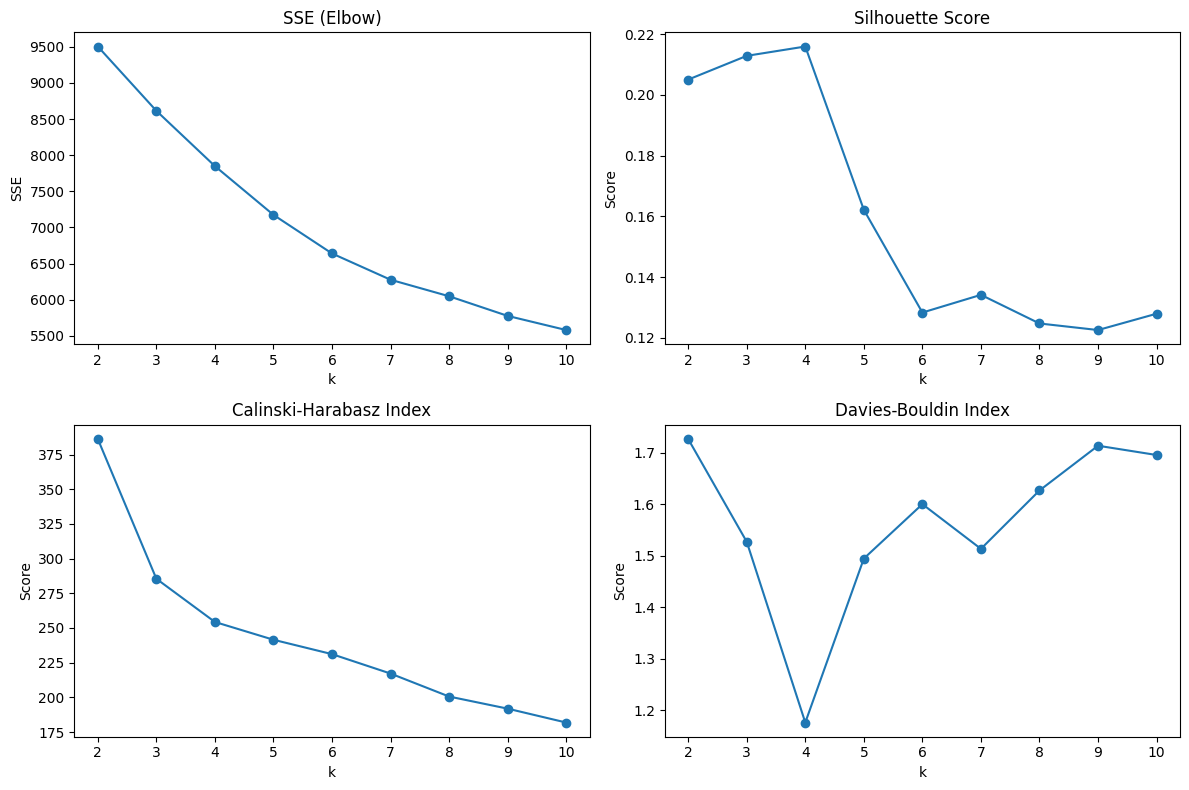

In [ ]:
# Getting the best k for the model

from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, calinski_harabasz_score, davies_bouldin_score)

X = df_wine_encoded.values
ks = range(2, 11)

sse = []
ch = []
sil = []
db = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X)

    sse.append(km.inertia_)
    ch.append(calinski_harabasz_score(X, labels))
    sil.append(silhouette_score(X, labels))
    db.append(davies_bouldin_score(X, labels))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# SSE
axes[0, 0].plot(ks, sse, marker="o")
axes[0, 0].set_title("SSE (Elbow)")
axes[0, 0].set_xlabel("k")
axes[0, 0].set_ylabel("SSE")

# Silhouette
axes[0, 1].plot(ks, sil, marker="o")
axes[0, 1].set_title("Silhouette Score")
axes[0, 1].set_xlabel("k")
axes[0, 1].set_ylabel("Score")

# Calinski-Harabasz
axes[1, 0].plot(ks, ch, marker="o")
axes[1, 0].set_title("Calinski-Harabasz Index")
axes[1, 0].set_xlabel("k")
axes[1, 0].set_ylabel("Score")

# Davies-Bouldin
axes[1, 1].plot(ks, db, marker="o")
axes[1, 1].set_title("Davies-Bouldin Index")
axes[1, 1].set_xlabel("k")
axes[1, 1].set_ylabel("Score")

plt.tight_layout()
plt.show()

- k = 4 is the strongest candidate. It has the highest silhouette score (0.216) and the lowest Davies–Bouldin index (1.17), meaning clusters are both well-separated and internally compact.

- Elbow appears around k = 4–5. SSE drops sharply until k=4 and then flattens, indicating diminishing returns beyond 4 clusters.

- Higher k values over-segment the data. After k=4, silhouette drops and DB worsens, while CH continuously declines suggesting added clusters create noise rather than meaningful segmentation.

In [ ]:
# Applying kmeans model
kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
kmeans_labels = kmeans.fit_predict(X)

df_wine_encoded["kmeans_labels"] = kmeans_labels + 1

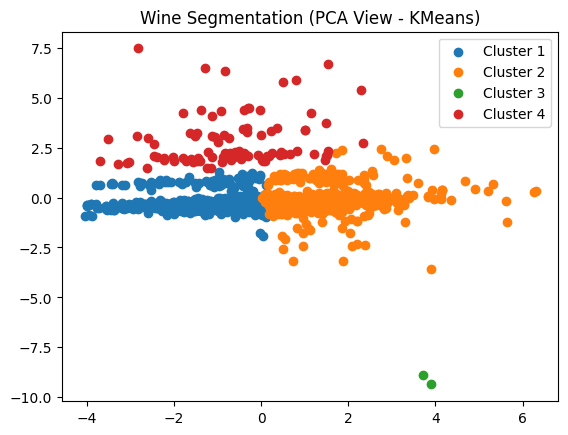

In [ ]:
# Visualize
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
unique_clusters = sorted(df_wine_encoded["kmeans_labels"].unique())

for cluster in unique_clusters:
    plt.scatter(
        X_pca[df_wine_encoded["kmeans_labels"] == cluster, 0],
        X_pca[df_wine_encoded["kmeans_labels"] == cluster, 1],
        label=f"Cluster {cluster}")

plt.legend()
plt.title("Wine Segmentation (PCA View - KMeans)")
plt.show()

In [ ]:
# Check Cluster Size
df_wine_encoded["kmeans_labels"].value_counts()

,count
kmeans_labels,
1,685
2,631
4,90
3,2


### Ward's Method Clustering

In [ ]:
# For dendogram plotting
from scipy.cluster.hierarchy import dendrogram, linkage

def plot1(Z):
    fig, ax = plt.subplots()
    dendrogram(Z, ax=ax, truncate_mode='lastp', p=10)
    ax.set_ylabel(r"$\Delta$")
    return ax

<Axes: ylabel='$\\Delta$'>

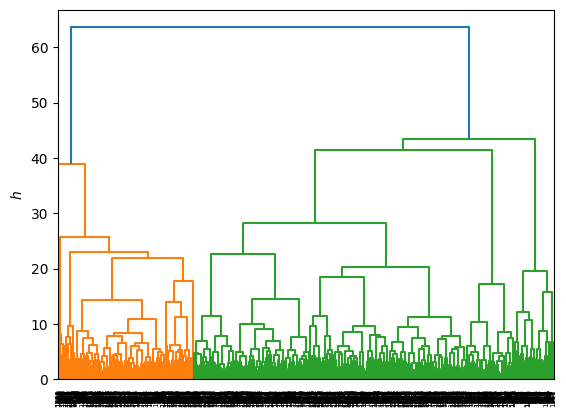

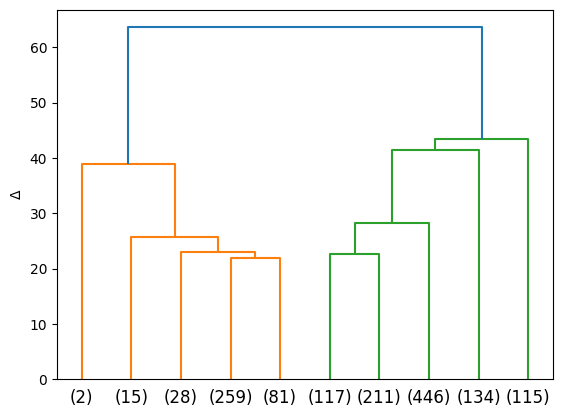

In [ ]:
# Checking for the optimal cut
Z = linkage(X, method="ward", optimal_ordering=True)
fig, ax = plt.subplots()
dn = dendrogram(Z, ax=ax)
ax.set_ylabel(r"$h$");
plot1(Z)

- Major structural split occurs around Δ = 60. Cutting just below this level (55) produces 2 large, clearly separated clusters, representing the strongest natural division in the data.

- A secondary meaningful cut appears around Δ = 35. This level yields approximately 4 clusters, aligning well with your KMeans result (k=4).

- For business segmentation, k = 4 is preferred. It captures deeper structure beyond the two broad groups while remaining stable and supported by validation metrics (Silhouette, DB, Elbow).

In [ ]:
# Applying ward's method

from scipy.cluster.hierarchy import fcluster
wards_label = fcluster(Z, t=35, criterion="distance")

df_wine_encoded["wards_label"] = wards_label

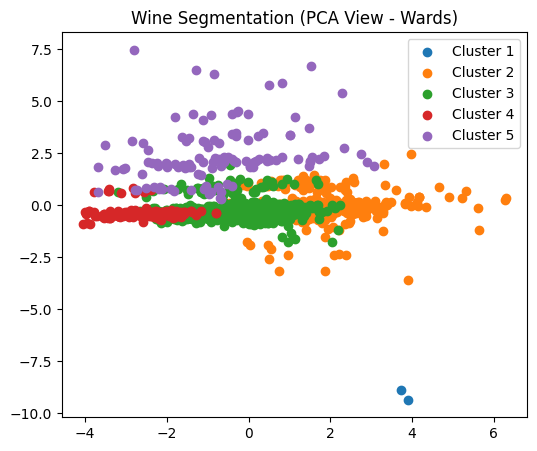

In [ ]:
# Visualize

plt.figure(figsize=(6,5))

for cluster in sorted(df_wine_encoded["wards_label"].unique()):
    mask = df_wine_encoded["wards_label"] == cluster
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=f"Cluster {cluster}")

plt.title("Wine Segmentation (PCA View - Wards)")
plt.legend()
plt.show()

In [ ]:
# Check Cluster Size
df_wine_encoded["wards_label"].value_counts()

,count
wards_label,
3,774
2,383
4,134
5,115
1,2


## 10. Cluster Analysis

In [ ]:
df_final = df_wine_cleaned.copy()

# Attaching kmeans label
df_final["kmeans_labels"] = df_wine_encoded["kmeans_labels"]

# Attaching wards label
df_final["wards_label"] = df_wine_encoded["wards_label"]

In [ ]:
df_final.head()

,Num Reviews,Alcoholic Degree,Type,Wine Class,Region,Log_Price,Grape_Final,Is_Non_Vintage,Is_Multi_Vintage,Wine_Age,Oak_Aged,Oak_Months,Storage_Potential_Years,kmeans_labels,wards_label
0,0,14.0,Tinto,Fino,Serra Gaúcha,5.583496,Tannat,0,0,5.0,1,24.0,10.0,2,2
1,1,14.0,Branco,Fino,Campanha Gaúcha,5.192957,Chardonnay,0,0,3.0,1,12.0,6.0,2,3
2,0,12.5,Tinto,Fino,Serra Gaúcha,4.844187,Other,0,0,5.0,0,0.0,6.0,1,3
3,1,12.9,Tinto,Fino,Minas Gerais,4.603168,Shiraz,0,0,5.0,1,6.0,6.0,2,3
4,0,13.5,Tinto,Fino,São Paulo,5.111988,Cabernet Franc,0,0,4.0,1,12.0,10.0,2,2


### KMeans Interpretations

In [ ]:
df_final.groupby("kmeans_labels").mean(numeric_only=True)

,Num Reviews,Alcoholic Degree,Log_Price,Is_Non_Vintage,Is_Multi_Vintage,Wine_Age,Oak_Aged,Oak_Months,Storage_Potential_Years,wards_label
kmeans_labels,,,,,,,,,,
1,0.108029,12.316190,4.205326,0.270073,0.001460,3.456934,0.229197,1.456934,3.853285,3.246715
2,0.133122,13.623724,5.155243,0.031696,0.038035,4.820919,0.896989,11.768621,8.064184,2.419968
3,0.000000,13.000000,6.551080,0.000000,0.000000,72.000000,0.000000,0.000000,5.000000,1.000000
4,2.733333,12.667222,4.229188,0.200000,0.011111,3.622222,0.544444,5.444444,5.011111,4.977778


#### KMeans Wine Segmentation Summary

| Cluster | Segment Name                     | Size | Share (%) | Price Level      | Structure & Aging                                      | Demand                          | Key Characteristics                                              | Strategic Action                                                                  |
|---------|----------------------------------|------|----------:|------------------|--------------------------------------------------------|----------------------------------|------------------------------------------------------------------|-----------------------------------------------------------------------------------|
| 1       | Everyday Accessible Wines        | 685  |  51.98%   | Below average     | Low alcohol, minimal oak, short storage potential      | Moderate                         | Mostly Fino class, mix of Branco & Tinto, Serra Gaúcha heavy    | Focus on volume and controlled promotions; protect margin (avoid deep discounting) |
| 2       | Premium Oak-Aged Structured Reds | 631  |  47.88%   | Above average     | Higher alcohol, strong oak aging (~12 mo), long storage| Moderate                         | Predominantly Tinto, strong oak influence, aging potential      | Primary margin driver — premium positioning, storytelling, price optimization     |
| 3       | Rare Vintage Outliers            | 2    |   0.15%   | Extremely high    | Ultra-aged wines (~70+ yrs), niche inventory           | Low (very limited items)         | Rare, legacy vintages, luxury positioning                       | Maintain exclusivity; no discounting; position as boutique luxury offerings        |
| 4       | High-Demand Value Reds           | 90   |   6.83%   | Below to average  | Moderate oak and aging                                 | Very high (highest review rate)  | Popular Tinto wines with strong customer engagement             | Possible underpricing — evaluate selective price increase or premium bundling      |

### Ward's Method Interpretations

In [ ]:
df_final.groupby("wards_label").mean(numeric_only=True)

,Num Reviews,Alcoholic Degree,Log_Price,Is_Non_Vintage,Is_Multi_Vintage,Wine_Age,Oak_Aged,Oak_Months,Storage_Potential_Years,kmeans_labels
wards_label,,,,,,,,,,
1,0.000000,13.000000,6.551080,0.000000,0.000000,72.000000,0.000000,0.000000,5.000000,3.000000
2,0.161880,13.761775,5.219315,0.033943,0.044386,5.386423,0.955614,13.939948,9.137076,1.981723
3,0.074935,12.879199,4.618628,0.098191,0.009044,3.545220,0.449612,3.851421,4.839793,1.326873
4,0.067164,11.030597,3.367766,0.798507,0.000000,3.843284,0.007463,0.022388,2.742537,1.000000
5,2.391304,12.659565,4.253365,0.234783,0.017391,3.600000,0.495652,5.139130,4.921739,3.365217


#### Wards Wine Segmentation Summary

| Cluster | Segment Name                      | Size | Share (%) | Price Level    | Structure & Aging                                        | Demand                          | Key Characteristics                                                | Strategic Action                                                                 |
|---------|-----------------------------------|------|----------:|----------------|----------------------------------------------------------|----------------------------------|--------------------------------------------------------------------|----------------------------------------------------------------------------------|
| 1       | Rare Vintage Prestige             | 2    | 0.15%     | Extremely high | Ultra-aged wines (~70+ yrs), niche inventory            | Low                             | 100% Tinto, luxury positioning, rare legacy vintages              | Maintain exclusivity; no discounting; treat as boutique luxury assets            |
| 2       | Premium Oak-Aged Structured Reds  | 386  | 27.42%    | High           | Very high oak aging (~14 mo), strong aging potential     | Moderate                        | ~97% Tinto, oak-dominant profile                                  | Core margin engine — controlled price increases & premium storytelling          |
| 3       | Balanced Mid-Tier Wines           | 771  | 54.76%    | Near average   | Moderate oak, balanced aging                             | Moderate                        | Mixed Branco/Tinto, mostly Fino class                             | Portfolio stability segment — competitive pricing & cross-sell focus            |
| 4       | Entry-Level Light Wines           | 134  | 9.52%     | Very low       | Minimal oak, short aging, high non-vintage concentration | Low                             | High non-vintage share, Serra Gaúcha heavy                        | Volume play — cost control, promo-efficient bundling                            |
| 5       | High-Demand Value Reds            | 115  | 8.17%     | Below average  | Moderate structure, moderate oak                         | Very high (highest reviews)     | Popular Tinto wines, strong customer engagement                   | Likely underpriced — test selective price increases or premium bundling         |

## 11. Final Model Selection - Ward's Method


- Although K-Means provided a stable four-tier segmentation, hierarchical clustering using Ward’s method produced a more granular and portfolio-aligned structure.

- Ward’s solution revealed five economically meaningful tiers: rare luxury, premium structured, balanced core, entry-level volume, and high-demand value wines.

- Given its stronger alignment with strategic pricing, promotion, and inventory logic, Ward’s segmentation is adopted as the final operational framework, with K-Means serving as robustness validation.

## 12. Price & Margin Contribution Analysis

In [ ]:
# Convert back the original price
df_final["Price_Approx"] = np.expm1(df_final["Log_Price"])

In [ ]:
df_final.groupby("wards_label")["Price_Approx"].sum()

,Price_Approx
wards_label,
1,1398.00
2,83650.34
3,92754.50
4,4212.30
5,10434.90


### Ward Cluster Price & Strategic Insights

#### Size and Price Comparisons

In [ ]:
# Cluster size %
size_pct = (
    df_final["wards_label"]
    .value_counts(normalize=True)
    .sort_index()
    * 100)

# Cluster price %
price_pct = (
    df_final.groupby("wards_label")["Price_Approx"]
    .sum()
    / df_final["Price_Approx"].sum()
    * 100)

cluster_summary = pd.DataFrame({
    "Size_Count": df_final["wards_label"].value_counts().sort_index(),
    "Size_%": size_pct.round(2),
    "Price_Total": df_final.groupby("wards_label")["Price_Approx"].sum().round(0),
    "Price_%": price_pct.round(2)})

cluster_summary

,Size_Count,Size_%,Price_Total,Price_%
wards_label,,,,
1,2,0.14,1398.0,0.73
2,383,27.20,83650.0,43.47
3,774,54.97,92754.0,48.20
4,134,9.52,4212.0,2.19
5,115,8.17,10435.0,5.42


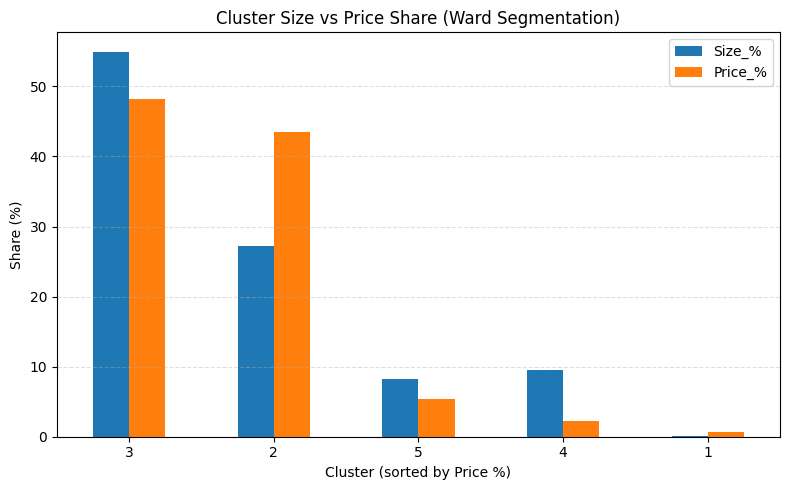

In [ ]:
cluster_compare = pd.DataFrame({
    "Size_%": size_pct.round(2),
    "Price_%": price_pct.round(2)
}).sort_index()

# Sort by Revenue_% (largest to smallest)
cluster_compare_sorted = cluster_compare.sort_values(
    by="Price_%",
    ascending=False)

# Plot
cluster_compare_sorted.plot(kind="bar", figsize=(8,5))
plt.title("Cluster Size vs Price Share (Ward Segmentation)")
plt.ylabel("Share (%)")
plt.xlabel("Cluster (sorted by Price %)")
plt.xticks(rotation=0)
plt.legend(title="")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

| Cluster | Revenue Share | Role in Portfolio        | Pricing Power | Demand Level | Risk Level | Strategic Priority | Key Action |
|----------|--------------|--------------------------|---------------|--------------|------------|-------------------|------------|
| 1 | 1% | Rare Vintage Prestige | Very High | Very Low | Low | Brand positioning | Maintain exclusivity; no discounting |
| 2 | 44% | Premium Structured Engine | High | Moderate | Medium | Margin protection | Protect pricing integrity; limit discount depth; premium storytelling |
| 3 | 48% | Core Revenue Backbone | Medium | Moderate | Medium | Portfolio stability | Maintain competitive pricing; rationalize redundant SKUs |
| 4 | 2% | Entry-Level Volume | Low | Low | High (margin dilution) | Operational efficiency | Bundle strategy; tight cost control; controlled promotions |
| 5 | 5% | High-Demand Value Opportunity | Medium | Very High | Low | Margin expansion | Test selective price increase (+3–5%); premium bundling strategy |

### Value Density (Economic Efficiency) Insight

In [ ]:
cluster_summary["Value_Density"] = (
    cluster_summary["Price_%"] / cluster_summary["Size_%"]
).round(2)

cluster_summary["Value_Density"]

,Value_Density
wards_label,
1,5.21
2,1.60
3,0.88
4,0.23
5,0.66




To quantify economic efficiency per cluster, we compute:

**Value_Density = Price Share (%) ÷ SKU Share (%)**

Interpretation:
- **> 1.0** - Over-indexing (high value contribution per SKU)
- **≈ 1.0** - Balanced contribution
- **< 1.0** - Under-indexing (too many SKUs for too little value)

## 13. Business Importance

### Back to Business Question  

How can we segment wines into economically meaningful groups to optimize pricing, promotion, and inventory decisions that maximize overall gross margin?

### Executive Summary  

Using Ward hierarchical clustering, the wine portfolio was segmented into **five economically distinct clusters** based on pricing structure, demand proxy (reviews), aging characteristics, oak treatment, and style attributes.

The segmentation reveals meaningful differences in:

- Pricing power  
- Revenue contribution  
- Demand intensity  
- Margin risk exposure  

This enables differentiated pricing, promotion, and inventory strategies at the **cluster level** rather than the individual SKU level.

Revenue concentration is highly uneven: **98% of total portfolio revenue is driven by Clusters 2 and 3**, indicating that strategic optimization within these segments will have the largest margin impact.

### Limitations



- Revenue is proxied using price aggregation (true revenue requires quantity sold).
- Demand is approximated using review counts.
- Clustering reflects current portfolio structure and does not incorporate elasticity modeling.

### Cluster-Level Strategic Interpretation

#### Cluster 3 – Core Revenue Backbone  
- **Revenue Share:** 48%  
- **SKU Share:** 55%  
- **Value Density:** 0.88 (Slightly under-indexing)  
- **Pricing Power:** Medium  
- **Demand Level:** Moderate  
- **Risk Level:** Medium  

**Insight:**  
This is the largest and most stable segment, contributing nearly half of total portfolio revenue. However, revenue contribution is slightly lower than its SKU share (Value Density < 1), suggesting crowding and internal substitution risk.

**Strategic Action:**  
- Maintain competitive pricing  
- Rationalize redundant SKUs  
- Optimize assortment depth  
- Monitor margin compression  

This cluster drives **portfolio stability**, not differentiation.

#### Cluster 2 – Premium Structured Engine  
- **Revenue Share:** 44%  
- **SKU Share:** 27%  
- **Value Density:** 1.60 (Strong over-indexing)  
- **Pricing Power:** High  
- **Demand Level:** Moderate  
- **Risk Level:** Medium  

**Insight:**  
High revenue concentration with fewer SKUs indicates stronger pricing integrity and higher per-product contribution. Revenue share significantly exceeds SKU share, confirming superior economic efficiency.

**Strategic Action:**  
- Protect pricing integrity  
- Limit discount depth  
- Emphasize premium positioning and storytelling  
- Avoid over-promotion  

This cluster is the **margin anchor of the portfolio**.

#### Cluster 5 – High-Demand Value Opportunity  
- **Revenue Share:** 5%  
- **SKU Share:** 8%  
- **Value Density:** 0.66 (Under-indexing)  
- **Pricing Power:** Medium  
- **Demand Level:** Very High  
- **Risk Level:** Low  

**Insight:**  
Demand is strong relative to price, suggesting potential underpricing. However, revenue contribution trails SKU presence (Value Density < 1), indicating margin upside.

**Strategic Action:**  
- Test selective price increases (+3–5%)  
- Monitor elasticity carefully  
- Explore premium bundling strategy  

This cluster represents a **margin expansion opportunity**.

#### Cluster 4 – Entry-Level Volume  
- **Revenue Share:** 2%  
- **SKU Share:** 9.5%  
- **Value Density:** 0.23 (Severe under-indexing)  
- **Pricing Power:** Low  
- **Demand Level:** Low  
- **Risk Level:** High (margin dilution)  

**Insight:**  
This segment has a disproportionately high SKU count relative to revenue contribution, indicating structural inefficiency and margin dilution risk.

**Strategic Action:**  
- Prune underperforming SKUs  
- Apply bundle strategy rather than heavy discounting  
- Enforce strict cost control  

This cluster poses **profitability risk if unmanaged**.


#### Cluster 1 – Rare Vintage Prestige  
- **Revenue Share:** <1%  
- **SKU Share:** <1%  
- **Value Density:** 5.21 (Extreme over-indexing)  
- **Pricing Power:** Very High  
- **Demand Level:** Very Low  
- **Risk Level:** Low  

**Insight:**  
Extremely small but highly efficient on a per-SKU basis. Acts as a prestige or halo segment, enhancing brand perception rather than driving volume revenue.

**Strategic Action:**  
- Maintain exclusivity  
- Avoid discounting  
- Position as prestige or limited-release products  

This cluster contributes to **brand equity rather than volume revenue**.

### Final Strategic Conclusion  

The segmentation demonstrates that margin optimization should be managed at the **cluster level**, not the individual SKU level, because:

- Clusters exhibit distinct pricing power and demand characteristics.  
- Revenue concentration is heavily skewed toward economically efficient segments (Clusters 2 and 3).  
- Value Density highlights over-performing and under-performing segments.  
- Certain clusters present margin expansion opportunities (Cluster 5), while others pose dilution risks (Cluster 4).  

By implementing differentiated pricing and assortment strategies per cluster, the company can:

- Protect premium pricing integrity  
- Reduce internal price cannibalization  
- Improve gross margin  
- Rationalize low-performing inventory  
- Allocate promotional budget more effectively  

This confirms that **data-driven clustering creates economically actionable segmentation**, directly supporting margin optimization objectives.